# ✈️ ניתוח תפעולי וזיהוי צווארי בקבוק בעיכובי טיסות

## 🎯 מטרת הפרויקט
בניית פרויקט ניתוח נתונים תפעולי מקצה לקצה למיפוי נתונים, חישוב מדדי ביצוע מרכזיים, תחקור בשאילתות SQL וזיהוי צווארי בקבוק בעיכובי טיסות מסחריות.

## 💼 הבעיה העסקית והתפעולית
עיכובי טיסות עולים לחברות תעופה ולשדות תעופה מיליארדי דולרים מדי שנה בשל הפסדי שעות צוות, צריכת דלק מוגברת, קנסות ושחיקה בשביעות רצון הנוסעים. ניתוח מוקדם מציע:
1. **שיפור ניהול הממשקים:** הקצאה גמישה של צוותי קרקע ואוויר וניהול שערים בשעות עומס.
2. **אופטימיזציה של לוחות זמנים:** הוספת מרווחי ביטחון מושכלים בנתיבים ובשעות בעייתיות.
3. **חיסכון כלכלי:** צמצום עלויות תפעוליות ישירות הנובעות מעיכובים מצטברים.

## 🛠️ ארכיטקטורת הפרויקט ושלבי העבודה
1. **ניקוי והכנת הנתונים:** טיפול בערכים חסרים, ניקוי כפילויות והגדרת עמודת המטרה (`IS_DELAYED`).
2. **הנדסת תכונות:** גזירת תכונות תפעוליות: שעת המראה (`DEP_HOUR`), נתיב (`ROUTE`) ונפח תנועה בשדה המוצא (`ORIGIN_TRAFFIC`).
3. **ניתוח נתונים חוקר (EDA):** ניתוח ויזואלי לזיהוי אפקט הצטברות העיכובים לאורך היום וחברות התעופה המובילות בעיכובים.
4. **תחקור בסיס נתונים ב-SQL:** הרצת שאילתות ANSI SQL באמצעות מנוע DuckDB לחילוץ שדות התעופה הבעייתיים ביותר.
5. **מדדים תפעוליים והמלצות ניהוליות:** חישוב אובדן שעות עיכוב מצטבר וגיבוש המלצות אופרטיביות.

In [49]:
import pandas as pd

file_path = 'data/flights_sample_3m.csv'

df = pd.read_csv(file_path)

df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [50]:
df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')

In [51]:
# סריקה ראשונית: מבנה הנתונים, סוגי העמודות וערכים חסרים
print("--- מידע כללי על הטבלה ---")
print(df.info())
    
print("\n--- ערכים חסרים בכל עמודה ---")
print(df.isnull().sum())

print("\n--- כמות שורות וכמות עמודות ---")
print(df.shape)

--- מידע כללי על הטבלה ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED          

In [52]:

df_clean = df.copy()

initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"הוסרו {initial_rows - len(df_clean)} שורות כפולות.")

print("מספר הטבלה הנקייה (שורות, עמודות):", df_clean.shape)

df_clean.head()

הוסרו 0 שורות כפולות.
מספר הטבלה הנקייה (שורות, עמודות): (3000000, 32)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [53]:
# 1. בדיקת כמות האחוזים של ערכים חסרים בכל עמודה
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100
print("--- אחוז הערכים החסרים לפי עמודה ---")
print(missing_percentage[missing_percentage > 0])

# 2. מילוי ערכים חסרים בדקות עיכוב ב-0 (מתוך הנחה שחסר פירושו לא היה עיכוב)
delay_columns = [col for col in df_clean.columns if 'Delay' in col or 'delay' in col]
df_clean[delay_columns] = df_clean[delay_columns].fillna(0)

print("\nערכים חסרים בעמודות עיכוב טופלו בהצלחה!")

--- אחוז הערכים החסרים לפי עמודה ---
DEP_TIME                    2.587167
DEP_DELAY                   2.588133
TAXI_OUT                    2.626867
WHEELS_OFF                  2.626867
WHEELS_ON                   2.664800
TAXI_IN                     2.664800
ARR_TIME                    2.664733
ARR_DELAY                   2.873267
CANCELLATION_CODE          97.362000
CRS_ELAPSED_TIME            0.000467
ELAPSED_TIME                2.873267
AIR_TIME                    2.873267
DELAY_DUE_CARRIER          82.204567
DELAY_DUE_WEATHER          82.204567
DELAY_DUE_NAS              82.204567
DELAY_DUE_SECURITY         82.204567
DELAY_DUE_LATE_AIRCRAFT    82.204567
dtype: float64

ערכים חסרים בעמודות עיכוב טופלו בהצלחה!


In [75]:
# יצירת עמודת המטרה: 1 אם היה עיכוב של 15 דקות ומעלה בהמראה או בהגעה, אחרת 0
df_clean['IS_DELAYED'] = ((df_clean['ARR_DELAY'] >= 15) | (df_clean['DEP_DELAY'] >= 15)).astype(int)

# בדיקת אחוז הטיסות המעוכבות מול הטיסות בזמן
print("--- אחוז הטיסות המעוכבות (IS_DELAYED) ---")
print(df_clean['IS_DELAYED'].value_counts(normalize=True) * 100)

--- אחוז הטיסות המעוכבות (IS_DELAYED) ---
IS_DELAYED
0    78.450367
1    21.549633
Name: proportion, dtype: float64


<div dir="rtl">

## 💡 תובנות מפתח מניתוח עמודת המטרה (`Target Variable Insights`)

* **שיעור העיכובים הכללי:** כ-**21.55%** מכלל הטיסות ב-Dataset סובלות מעיכוב משמעותי (של 15 דקות ומעלה) בהמראה או בהגעה.
* **איזון הנתונים (`Class Imbalance`):** רוב הטיסות (**78.45%**) יוצאות ומגיעות בזמן. מדובר בהתפלגות קלאסית בעולם התעופה, ונכניס נתון זה בחשבון בעת אימון מודל ה-Machine Learning (למשל, מדידת ביצועים באמצעות F1-Score / ROC-AUC ולא רק Accuracy).
* **משמעות תפעולית:** זיהוי מוקדם של ה-21.5% המעוכבים יאפשר לחברות התעופה ולצוותי הקרקע להקצות משאבים מראש ולמנוע עיכובים שרשרתיים בשדות התעופה.

</div>

In [120]:
# 1. יצירת עמודת שעת ההמראה DEP_HOUR (מתוך CRS_DEP_TIME)
df_clean['DEP_HOUR'] = (df_clean['CRS_DEP_TIME'] // 100).astype(int)

# 2. יצירת עמודת נתיב הטיסה ROUTE
df_clean['ROUTE'] = df_clean['ORIGIN'] + '_' + df_clean['DEST']

# 3. חישוב עומס נפח התנועה בשדה המוצא ORIGIN_TRAFFIC
origin_counts = df_clean['ORIGIN'].value_counts()
df_clean['ORIGIN_TRAFFIC'] = df_clean['ORIGIN'].map(origin_counts)

print("כל העמודות הנדרשות נוצרו בהצלחה!")
df_clean[['DEP_HOUR', 'ROUTE', 'ORIGIN_TRAFFIC', 'IS_DELAYED']].head()

כל העמודות הנדרשות נוצרו בהצלחה!


,DEP_HOUR,ROUTE,ORIGIN_TRAFFIC,IS_DELAYED
0,11,FLL_EWR,40276,0
1,21,MSP_SEA,60061,0
2,9,DEN_MSP,119919,0
3,16,MSP_SFO,60061,1
4,18,MCO_DFW,63883,0


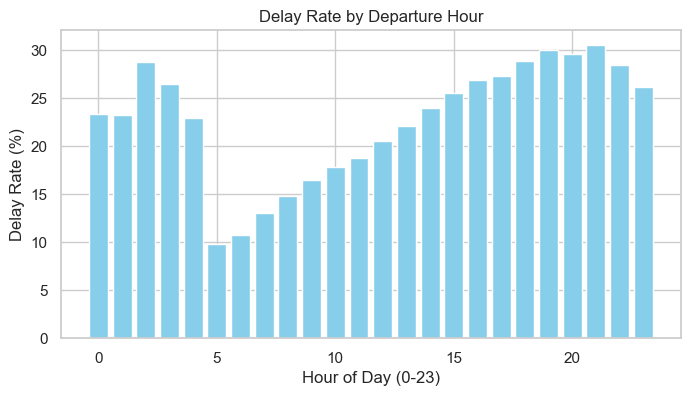

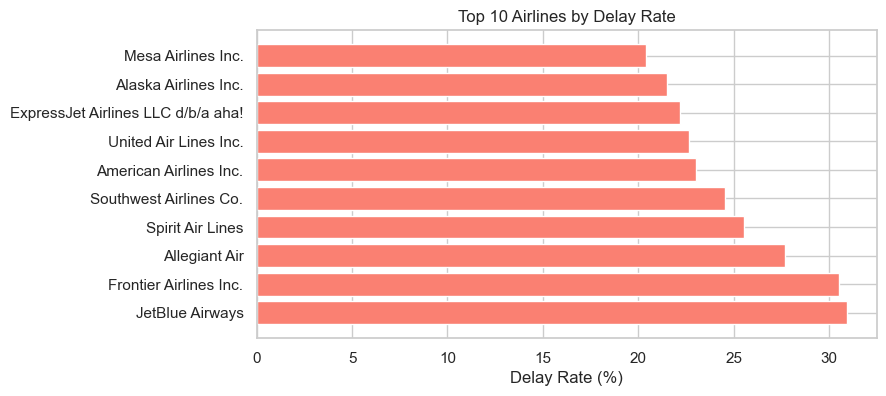

In [91]:
import matplotlib.pyplot as plt

# 1. גרף אחוז עיכובים לפי שעת המראה ביום
hourly_delay = df_clean.groupby('DEP_HOUR')['IS_DELAYED'].mean() * 100

plt.figure(figsize=(8, 4))
plt.bar(hourly_delay.index, hourly_delay.values, color='skyblue')
plt.title('Delay Rate by Departure Hour')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Delay Rate (%)')
plt.show()

# 2. גרף Top 10 חברות תעופה עם אחוז העיכוב הגבוה ביותר
airline_delay = df_clean.groupby('AIRLINE')['IS_DELAYED'].mean().sort_values(ascending=False).head(10) * 100

plt.figure(figsize=(8, 4))
plt.barh(airline_delay.index, airline_delay.values, color='salmon')
plt.title('Top 10 Airlines by Delay Rate')
plt.xlabel('Delay Rate (%)')
plt.show()

In [93]:
# 1. 10 הנתיבים (Routes) עם אחוז העיכובים הגבוה ביותר (עבור נתיבים עם לפחות 100 טיסות)
route_stats = df_clean.groupby('ROUTE').agg(total_flights=('IS_DELAYED', 'count'),delay_rate=('IS_DELAYED', 'mean'))
top_delayed_routes = route_stats[route_stats['total_flights'] >= 100]['delay_rate'].sort_values(ascending=False).head(10) * 100

print("--- Top 10 הנתיבים הבעייתיים ביותר (אחוז עיכוב) ---")
print(top_delayed_routes.round(2))

# 2. 10 שדות התעופה העמוסים ביותר
print("\n--- Top 10 שדות התעופה העמוסים ביותר (נפח המראות) ---")
print(df_clean['ORIGIN'].value_counts().head(10))

--- Top 10 הנתיבים הבעייתיים ביותר (אחוז עיכוב) ---
ROUTE
MEM_LAS    55.06
EWR_SMF    52.07
BDL_SJU    50.16
SAN_FLL    48.78
EWR_BQN    47.02
FWA_PGD    46.53
RNO_JFK    45.54
MDW_EWR    45.20
JFK_ONT    45.19
FNT_PGD    45.00
Name: delay_rate, dtype: float64

--- Top 10 שדות התעופה העמוסים ביותר (נפח המראות) ---
ORIGIN
ATL    153556
DFW    130334
ORD    122296
DEN    119919
CLT     94304
LAX     85872
PHX     74815
LAS     73470
SEA     70906
MCO     63883
Name: count, dtype: int64


<div dir="rtl">

## 📊 תובנות מרכזיות מניתוח הגרפים (EDA Insights)

* **אפקט הצטברות העיכובים לאורך היום (`Delay Rate by Departure Hour`):**
  * **שעת שפל:** בשעה 05:00 בבוקר נרשם אחוז העיכובים הנמוך ביותר ביום (**כ-10% בלבד**).
  * **עלייה עקבית:** החל מ-05:00 בבוקר, אחוז העיכובים עולה בהתמדה כמעט מדי שעה ומגיע לשיא בשעות הלילה (20:00–21:00) עם **מעל 30% עיכובים**.
  * **משמעות תפעולית:** עיכובים קטנים בבוקר יוצרים "אפקט דומינו" שמחריף לקראת סוף היום.

* **חברות התעופה הבעייתיות ביותר (`Top 10 Airlines by Delay Rate`):**
  * **שיאנית העיכובים:** חברת **JetBlue Airways** מובילה בראש הרשימה עם אחוז העיכובים הגבוה ביותר (כ-**31%**), ומיד אחריה **Frontier Airlines** (כ-**30.5%**).
  * **טווח העיכובים:** כל 10 החברות ברשימה סובלות משיעור עיכובים גבוה במיוחד שבין 20% ל-31%.

</div>

In [98]:
# 1. חישוב סך דקות ושעות העיכוב ב-Dataset
total_delay_minutes = df_clean['ARR_DELAY'].clip(lower=0).sum()
total_delay_hours = total_delay_minutes / 60

# 2. ממוצע זמן עיכוב לטיסה (רק מתוך הטיסות שאיחרו)
avg_delay_per_delayed_flight = df_clean[df_clean['IS_DELAYED'] == 1]['ARR_DELAY'].mean()

print("=== מדדים תפעוליים מרכזיים (Operational KPIs) ===")
print(f"סך כל שעות העיכוב שנצברו: {total_delay_hours:,.0f} שעות")
print(f"זמן עיכוב ממוצע לטיסה מעוכבת: {avg_delay_per_delayed_flight:.1f} דקות")

=== מדדים תפעוליים מרכזיים (Operational KPIs) ===
סך כל שעות העיכוב שנצברו: 647,984 שעות
זמן עיכוב ממוצע לטיסה מעוכבת: 57.0 דקות


<div dir="rtl">

## 📌 סיכום מנהלים והמלצות תפעוליות (Executive Summary & Recommendations)

### 📊 ממצאים מרכזיים:
1. **היקף הבעיה:** כ-**21.55%** מכלל הטיסות חווות עיכוב משמעותי של 15 דקות ומעלה.
2. **דינמיקת זמנים:** נרשמה עלייה עקבית באחוז העיכובים לאורך היום – מ-**10% בלבד ב-05:00 בבוקר** ועד לשיא של **מעל 30% בשעות הלילה (20:00–21:00)** עקב אפקט מצטבר (Cascading Delays).
3. **שונות בין חברות:** חברות כמו **JetBlue** ו-**Frontier** מציגות שיעורי עיכוב גבוהים במיוחד (כ-30%-31%), לעומת חברות יציבות יותר.

### 💡 המלצות אופרטיביות לניהול הצי והשדות:
* **הוספת מרווחי ביטחון (Buffers):** להגדיל את זמן השהייה על הקרקע (Turnaround Time) עבור טיסות המתוכננות לאחרי הצהריים והערב, כדי לבלום את התפשטות העיכובים המצטברים.
* **תיעודף משאבים בשדות עמוסים:** לרכז צוותי קרקע מתוגברים בשדות התעופה המרכזיים (כדוגמת ATL, DFW ו-ORD) בשעות עומס השיא (16:00–21:00).
* **ניהול חוזים מול חברות תעופה:** להגדיר מדדי שירות (SLA) נוקשים יותר מול חברות תעופה שחורגות באופן רציף מ-25% עיכובים.

</div>

<div dir="rtl">

## 🔍 ניתוח תפעולי באמצעות שאילתות SQL (`SQL Operational Analysis`)

כדי לבחון את תהליכי הפקת התובנות דרך כלי תחקור נוסף, נעשה שימוש במנוע **DuckDB** להרצת שאילתות ANSI SQL ישירות על גבי ה-Dataset המנוקה (`df_clean`).

**מטרת השאילתה:** זיהוי 5 שדות התעופה העמוסים ביותר (נפח של מעל 50,000 המראות) בעלי שיעור העיכובים הגבוה ביותר, לצד חישוב ממוצע דקות העיכוב לטיסה.

</div>

In [109]:
pip install duckdb

Note: you may need to restart the kernel to use updated packages.


In [113]:
import duckdb

# שאילתת SQL לזיהוי 5 שדות התעופה הבעייתיים ביותר
sql_query = """
    SELECT 
        ORIGIN AS airport_code,
        COUNT(*) AS total_flights,
        ROUND(AVG(IS_DELAYED) * 100, 2) AS delay_rate_pct,
        ROUND(AVG(ARR_DELAY), 1) AS avg_arrival_delay_min
    FROM df_clean
    GROUP BY ORIGIN
    HAVING COUNT(*) >= 50000
    ORDER BY delay_rate_pct DESC
    LIMIT 5
"""

# הרצת השאילתה מול ה-DataFrame
top_airports_sql = duckdb.query(sql_query).to_df()

print("--- תוצאות שאילתת SQL: Top 5 שדות תעופה בעייתיים ---")
top_airports_sql

--- תוצאות שאילתת SQL: Top 5 שדות תעופה בעייתיים ---


,airport_code,total_flights,delay_rate_pct,avg_arrival_delay_min
0,EWR,52989,28.44,8.7
1,DEN,119919,27.30,7.4
2,MCO,63883,27.10,9.9
3,LAS,73470,26.03,6.6
4,JFK,50466,25.40,3.3
